In [ ]:
# --- Cell 1: imports + load the saved calibration result ---
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src import config, calibration, model
from src.data.data import contact_matrix, data
from src.data import historical_population

with open(config.DATA_PROCESSED_DIR / "calibration_result.json") as f:
    fit = json.load(f)

beta_0 = fit["beta_0"]
beta_1 = fit["beta_1"]
phi = fit["phi"]
gamma_fixed = fit["gamma_fixed"]
vaccination_rates = np.array(fit["vaccination_rates"], dtype=float)
fit_start, fit_end = fit["fit_window"]["start"], fit["fit_window"]["end"]

# birth_rate/death_rate are no longer flat floats in the saved file --
# the fit was scored against time-varying rates, and the JSON only stores
# window-start/end snapshots for a sanity check, not the full function
# (see run_calibration.save_result). Rebuild the actual functions the
# same way run_calibration.py did, rather than reading a stale scalar.
birth_rate_fn, death_rate_fn = historical_population.build_vital_rate_functions()
fit_window_start_year = pd.Timestamp(fit_start).year

print(f"beta_0={beta_0:.4f}, beta_1={beta_1:.4f}, phi={phi:.4f}, "
      f"gamma_fixed={gamma_fixed:.4f}, window=[{fit_start}, {fit_end}), "
      f"final_loss={fit['final_loss']:.2f}")
print(f"saved snapshot check -- birth_rate at window start/end: "
      f"{fit['birth_rate_at_window_start']:.5f} / {fit['birth_rate_at_window_end']:.5f}, "
      f"rebuilt fn at window start: {birth_rate_fn(fit_window_start_year):.5f} "
      f"(should match the saved start snapshot)")

beta_0=689.2395, beta_1=0.1701, phi=5.6214, gamma_fixed=45.6562, window=[1950-01-01, 1960-01-01), final_loss=887930.35
saved snapshot check -- birth_rate at window start/end: 0.02410 / 0.02370, rebuilt fn at window start: 0.02410 (should match the saved start snapshot)


In [2]:
# --- Cell 2: rebuild the contact matrix and the observed series over the fit window ---
contact_matrix.build_processed_contact_matrix()
contact_matrix_df = contact_matrix.load_processed_contact_matrix()
contact_matrix_array = contact_matrix_df.to_numpy()

full_series = data.load_processed_series()
from scripts.run_calibration import restrict_date_range  # or copy the function if not importable
windowed_series = restrict_date_range(full_series, fit_start, fit_end)
observed_times = data.series_to_elapsed_years(windowed_series)
observed_case_counts = windowed_series["case_count"].to_numpy()

print(f"{len(windowed_series)} weekly observations, "
      f"t in [{observed_times[0]:.3f}, {observed_times[-1]:.3f}] years")

522 weekly observations, t in [0.000, 9.985] years


In [ ]:
# --- Cell 4: build_full_parameters now needs t-shifted callables, not the
# stale scalar snapshot -- same pattern run_calibration.py uses for the
# fit window itself (note: NOT the same shift burn-in used above; the
# fit window's own t=0 is fit_window_start_year, a different reference
# point than burn-in's start year) ---
birth_rate_of_t = lambda t: birth_rate_fn(fit_window_start_year + t)
death_rate_of_t = lambda t: death_rate_fn(fit_window_start_year + t)

best_fit_parameters = calibration.build_full_parameters(
    beta_0=beta_0,
    beta_1=beta_1,
    phi=phi,
    gamma=gamma_fixed,
    fixed_birth_rate=birth_rate_of_t,
    fixed_death_rate=death_rate_of_t,
    contact_matrix=contact_matrix_array,
)
best_fit_parameters["vaccination_rates"] = vaccination_rates

interval_ends, modeled_total, modeled_per_age = calibration.weekly_modeled_incidence(
    best_fit_parameters,
    initial_conditions,
    observed_times,
)

observed_compared = observed_case_counts[1:]

comparison_df = pd.DataFrame({
    "elapsed_years": interval_ends,
    "observed_cases": observed_compared,
    "modeled_incidence": modeled_total,
})
comparison_df["residual"] = comparison_df["modeled_incidence"] - comparison_df["observed_cases"]
comparison_df.head()

,elapsed_years,observed_cases,modeled_incidence,residual
0,0.019165,63.0,2132.295321,2069.295321
1,0.038330,98.0,2041.667864,1943.667864
2,0.057495,93.0,1999.877528,1906.877528
3,0.076660,181.0,2000.430190,1819.430190
4,0.095825,161.0,2035.560231,1874.560231


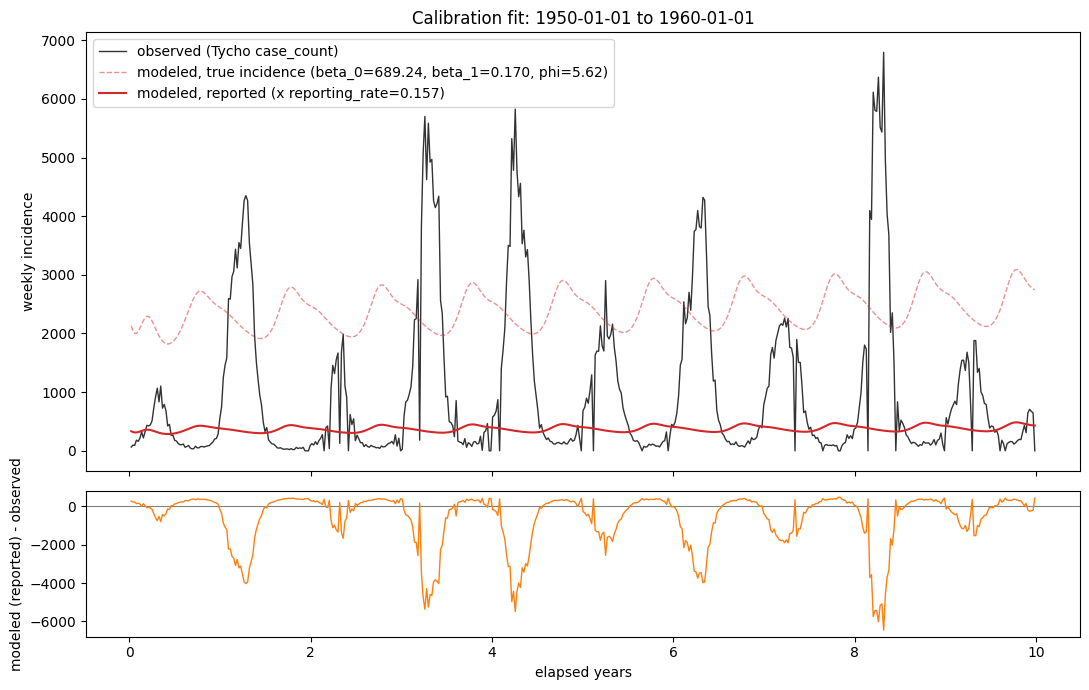

sum(modeled reported)/sum(observed) = 0.38  (should be close to 1.0 now)
mean per-point deviance    = 1704.3  (should be ~1 for a well-specified Poisson fit)


In [ ]:
# --- Cell 5: plot both true and reporting-scaled modeled incidence ---
reporting_rate = fit["reporting_rate_fixed"]  # CDC ~0.157, see calibration.FIXED_REPORTING_RATE
modeled_reported = comparison_df["modeled_incidence"] * reporting_rate

fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True,
                          gridspec_kw={"height_ratios": [3, 1]})

axes[0].plot(comparison_df["elapsed_years"], comparison_df["observed_cases"],
             label="observed (Tycho case_count)", color="black", lw=1, alpha=0.8)
axes[0].plot(comparison_df["elapsed_years"], comparison_df["modeled_incidence"],
             label=f"modeled, true incidence (beta_0={beta_0:.2f}, beta_1={beta_1:.3f}, phi={phi:.2f})",
             color="tab:red", lw=1, alpha=0.5, linestyle="--")
axes[0].plot(comparison_df["elapsed_years"], modeled_reported,
             label=f"modeled, reported (x reporting_rate={reporting_rate:.3f})",
             color="tab:red", lw=1.5)
axes[0].set_ylabel("weekly incidence")
axes[0].set_title(f"Calibration fit: {fit_start} to {fit_end}")
axes[0].legend()

# residual is scored against the *reported* curve (see
# calibration.make_residual_function) -- plot that one here, not the
# true-incidence residual, so this panel matches what was actually fit.
residual_reported = modeled_reported - comparison_df["observed_cases"]
axes[1].axhline(0, color="gray", lw=0.8)
axes[1].plot(comparison_df["elapsed_years"], residual_reported, color="tab:orange", lw=1)
axes[1].set_ylabel("modeled (reported) - observed")
axes[1].set_xlabel("elapsed years")

fig.tight_layout()
plt.show()

ratio = modeled_reported.sum() / comparison_df["observed_cases"].sum()
print(f"sum(modeled reported)/sum(observed) = {ratio:.2f}  (should be close to 1.0 now)")
print(f"mean per-point deviance    = {fit['final_loss'] / len(comparison_df):.1f}  "
      f"(should be ~1 for a well-specified Poisson fit)")

In [ ]:
import numpy as np
from src.data.data import contact_matrix
C = contact_matrix.load_processed_contact_matrix().to_numpy()
print(np.linalg.eigvals(C).real.max())  # rho(C)

13.433314718346903


In [ ]:
# =============================================================================
# DIAGNOSTIC v3
#   Step 0: verify jacobian.jac_ode_system against finite differences on a
#           realistic state, BEFORE trusting it in a real integration.
#   Step 1: burn-in cost/success, now trying Radau+analytic-Jacobian and
#           per-component atol, alongside the LSODA-scalar-atol run that
#           failed last time, for direct comparison.
#   Step 2: same comparison for the fit window, only for candidates whose
#           burn-in succeeded in step 1.
#
# Save jacobian.py alongside your src/ package (e.g. src/jacobian.py) and
# adjust the import below to match, or keep it next to this notebook and
# adjust sys.path.
# =============================================================================

import sys, time
import numpy as np

from src.data import historical_population

# adjust this path if jacobian.py isn't already importable as `src.jacobian`
sys.path.insert(0, "/mnt/user-data/outputs")
from src.data.data import contact_matrix as cm
import src.jacobian as jac_module

from src import config, model, calibration

FIT_START_YEAR = 1954
BURN_IN_YEARS = 80.0
N_WEEKS = 6 * 52
FIXED_GAMMA = config.FIXED_GAMMA_PER_YEAR
FIXED_SIGMA = config.CALIBRATION_FIXED_PARAMETERS["sigma"]
FIXED_MATERNAL_WANING = config.CALIBRATION_FIXED_PARAMETERS["maternal_waning_rate"]

contact_matrix_array = cm.load_processed_contact_matrix(config).to_numpy()

candidates = {
    "flat (current best fit)": dict(beta_0=690.92, beta_1=0.18, phi=5.57),
    "biennial candidate":      dict(beta_0=FIXED_GAMMA * 20.0, beta_1=0.28, phi=5.57),
}

birth_rate_fn, death_rate_fn = historical_population.build_vital_rate_functions()

def make_vital_rate_callables(start_year):
    def br(t):
        return birth_rate_fn(start_year + t)
    def dr(t):
        return death_rate_fn(start_year + t)
    return br, dr

burn_in_start_year = FIT_START_YEAR - BURN_IN_YEARS
br_burn, dr_burn = make_vital_rate_callables(burn_in_start_year)

# -----------------------------------------------------------------------
# Step 0: verify the analytic Jacobian on a plausible mid-simulation state
# (not t=0 -- want I/E away from zero and population mixed across groups,
# so the quotient-rule and birth-row terms actually get exercised).
# -----------------------------------------------------------------------
print("="*70)
print("STEP 0: analytic vs finite-difference Jacobian check")
print("="*70)

A = config.N_AGE_GROUPS
rng = np.random.default_rng(0)
N_per_group = 1e5 * rng.uniform(0.5, 2.0, size=A)
frac = rng.dirichlet(np.ones(5), size=A)  # random M/S/E/I/R split per group
M0 = frac[:, 0] * N_per_group
S0 = frac[:, 1] * N_per_group
E0 = frac[:, 2] * N_per_group
I0 = frac[:, 3] * N_per_group
R0 = frac[:, 4] * N_per_group
CumInc0 = np.zeros(A)
y_test = model.pack_state(M0, S0, E0, I0, R0, CumInc0)

test_params = calibration.build_full_parameters(
    690.92, 0.18, 5.57, FIXED_GAMMA, br_burn, dr_burn,
    contact_matrix_array, config,
    fixed_sigma=FIXED_SIGMA, fixed_maternal_waning_rate=FIXED_MATERNAL_WANING,
)

worst_rel_err = jac_module.check_jacobian_numerically(1.3, y_test, test_params)
if worst_rel_err > 1e-4:
    print(
        "  ^ WARNING: relative error above 1e-4 -- inspect before trusting "
        "the analytic Jacobian in a real run. (Some error is expected right "
        "at entries near zero; check the printed (row,col) against the "
        "derivation in jacobian.py's docstring.)"
    )
else:
    print("  looks correct -- proceeding.")

# -----------------------------------------------------------------------
# Step 1: burn-in, three configurations per candidate:
#   (a) LSODA, scalar atol=1e-3           -- what failed last time
#   (b) Radau,  analytic jac, array atol  -- the fix being tested
#   (c) LSODA,  analytic jac, array atol  -- isolate jac's effect alone
# -----------------------------------------------------------------------
print("\n" + "="*70)
print("STEP 1: burn-in, LSODA(scalar atol) vs Radau/LSODA(analytic jac, array atol)")
print("="*70)

def array_atol(A):
    # Per-compartment floors: ~1 person for I/E (where near-elimination
    # matters), looser for the large M/S/R pools, tiny for the pure
    # bookkeeping CumInc accumulator. Adjust the M/S/R floor if your
    # population scale differs a lot from ~millions.
    per_group = np.concatenate([
        np.full(A, 1e2),   # M
        np.full(A, 1e2),   # S
        np.full(A, 1.0),   # E
        np.full(A, 1.0),   # I
        np.full(A, 1e2),   # R
        np.full(A, 1e-2),  # CumInc
    ])
    return per_group

configs = {
    "LSODA scalar atol (old)": dict(method="LSODA", atol=1e-3, rtol=1e-6),
    "Radau + jac + array atol": dict(method="Radau", jac=jac_module.jac_ode_system,
                                      atol=array_atol(A), rtol=1e-6),
    "LSODA + jac + array atol": dict(method="LSODA", jac=jac_module.jac_ode_system,
                                      atol=array_atol(A), rtol=1e-6),
}

burn_in_results = {}  # (label, config_name) -> ic or None

for label, bp in candidates.items():
    for cfg_name, extra_kwargs in configs.items():
        t0 = time.time()
        status = "ok"
        ic = None
        try:
            ic = historical_population.initial_conditions_with_burn_in(
                fit_start_year=FIT_START_YEAR,
                burn_in_years=BURN_IN_YEARS,
                contact_matrix_array=contact_matrix_array,
                burn_in_beta_0=bp["beta_0"],
                burn_in_beta_1=bp["beta_1"],
                burn_in_phi=bp["phi"],
                burn_in_gamma=FIXED_GAMMA,
                burn_in_sigma=FIXED_SIGMA,
                burn_in_maternal_waning_rate=FIXED_MATERNAL_WANING,
                max_rhs_evals=1_000_000,
                **extra_kwargs,
            )
        except RuntimeError as e:
            status = f"RuntimeError: {e}"
        except Exception as e:
            status = f"{type(e).__name__}: {e}"
        wall = time.time() - t0
        burn_in_results[(label, cfg_name)] = ic
        min_I = None if ic is None else float(np.min(ic["I0"]))
        print(
            f"  {label:24s} | {cfg_name:26s} wall={wall:7.2f}s  "
            f"status={status[:55]:55s}  min(I0)={min_I}"
        )
    print()

# -----------------------------------------------------------------------
# Step 2: fit window, only for (candidate, config) pairs that produced a
# valid burn-in IC above.
# -----------------------------------------------------------------------
print("="*70)
print("STEP 2: fit window using each successful burn-in IC")
print("="*70)

br_fit, dr_fit = make_vital_rate_callables(FIT_START_YEAR)
times = np.linspace(0.0, N_WEEKS / 52.0, N_WEEKS + 1)

for (label, cfg_name), ic in burn_in_results.items():
    if ic is None:
        continue
    bp = candidates[label]
    full_params = calibration.build_full_parameters(
        bp["beta_0"], bp["beta_1"], bp["phi"], FIXED_GAMMA,
        br_fit, dr_fit, contact_matrix_array, config,
        fixed_sigma=FIXED_SIGMA, fixed_maternal_waning_rate=FIXED_MATERNAL_WANING,
    )
    extra_kwargs = configs[cfg_name]
    t0 = time.time()
    status = "ok"
    peak = trough = None
    try:
        _, weekly_total, _ = calibration.weekly_modeled_incidence(
            full_params, ic, times, max_rhs_evals=500_000, **extra_kwargs
        )
        peak, trough = float(weekly_total.max()), float(weekly_total.min())
    except RuntimeError as e:
        status = f"RuntimeError: {e}"
    except Exception as e:
        status = f"{type(e).__name__}: {e}"
    wall = time.time() - t0
    print(
        f"  {label:24s} | {cfg_name:26s} wall={wall:7.2f}s  "
        f"status={status[:45]:45s}  peak={peak}  trough={trough}"
    )

STEP 0: analytic vs finite-difference Jacobian check
max relative error: 4.319e-06 at J[8, 1]  (analytic=0.281584, numeric=0.281582)
  looks correct -- proceeding.

STEP 1: burn-in, LSODA(scalar atol) vs Radau/LSODA(analytic jac, array atol)
  flat (current best fit)  | LSODA scalar atol (old)    wall=  28.51s  status=RuntimeError: simulate_model exceeded max_rhs_evals=100  min(I0)=None
  flat (current best fit)  | Radau + jac + array atol   wall=  46.07s  status=RuntimeError: simulate_model exceeded max_rhs_evals=100  min(I0)=None
  flat (current best fit)  | LSODA + jac + array atol   wall=  67.63s  status=RuntimeError: simulate_model exceeded max_rhs_evals=100  min(I0)=None

  biennial candidate       | LSODA scalar atol (old)    wall=  29.12s  status=RuntimeError: simulate_model exceeded max_rhs_evals=100  min(I0)=None
  biennial candidate       | Radau + jac + array atol   wall=  46.29s  status=RuntimeError: simulate_model exceeded max_rhs_evals=100  min(I0)=None
  biennial candid

In [ ]:
# =============================================================================
# DIAGNOSTIC v4 -- does the burn-in actually need 80 years?
#
# Runs ONE integration per candidate, with checkpoints at several elapsed
# years, and reports how much the (normalized) state is still changing
# between checkpoints. If it's essentially flat well before 80 years, use a
# much shorter burn-in -- cuts wall-clock cost (and eval-cap exposure)
# proportionally, with no loss of accuracy.
#
# Uses Radau + analytic Jacobian + per-component atol (the config from v3
# that stopped crashing), with a generous eval cap since this is a
# one-off diagnostic, not something that runs inside the optimizer loop.
# =============================================================================

import sys, time
import numpy as np

from src.data import historical_population

sys.path.insert(0, "/mnt/user-data/outputs")
from src.data.data import contact_matrix as cm
import src.jacobian as jac_module

from src import config, model, calibration

FIT_START_YEAR = 1954
BURN_IN_YEARS = 80.0
CHECKPOINT_YEARS = [5, 10, 20, 30, 40, 60, 80]
FIXED_GAMMA = config.FIXED_GAMMA_PER_YEAR
FIXED_SIGMA = config.CALIBRATION_FIXED_PARAMETERS["sigma"]
FIXED_MATERNAL_WANING = config.CALIBRATION_FIXED_PARAMETERS["maternal_waning_rate"]

contact_matrix_array = cm.load_processed_contact_matrix(config).to_numpy()

candidates = {
    "flat (current best fit)": dict(beta_0=690.92, beta_1=0.18, phi=5.57),
    "biennial candidate":      dict(beta_0=FIXED_GAMMA * 20.0, beta_1=0.28, phi=5.57),
}

A = config.N_AGE_GROUPS

def array_atol(A):
    return np.concatenate([
        np.full(A, 1e2), np.full(A, 1e2), np.full(A, 1.0),
        np.full(A, 1.0), np.full(A, 1e2), np.full(A, 1e-2),
    ])

birth_rate_fn, death_rate_fn = historical_population.build_vital_rate_functions()
burn_in_start_year = FIT_START_YEAR - BURN_IN_YEARS

def birth_rate_of_t(t):
    return birth_rate_fn(burn_in_start_year + t)

def death_rate_of_t(t):
    return death_rate_fn(burn_in_start_year + t)

# naive starting IC, same as historical_population.initial_conditions_with_burn_in
# uses internally -- reproduced here since we want the raw trajectory with
# t_eval at checkpoints, not just the final state.
burn_in_start_population = historical_population.population_for_year(burn_in_start_year)
naive_ic = historical_population.initial_conditions_for_population(
    burn_in_start_population, cfg=config
)

for label, bp in candidates.items():
    print(f"\n{'='*70}\n{label}\n{'='*70}")

    burn_in_parameters = {
        "beta_0": float(bp["beta_0"]), "beta_1": float(bp["beta_1"]), "phi": float(bp["phi"]),
        "gamma": float(FIXED_GAMMA), "sigma": float(FIXED_SIGMA),
        "maternal_waning_rate": float(FIXED_MATERNAL_WANING),
        "birth_rate": birth_rate_of_t, "death_rate": death_rate_of_t,
        "vaccination_rates": np.asarray(config.CALIBRATION_FIXED_VACCINATION_RATES, dtype=float),
        "contact_matrix": contact_matrix_array,
    }

    t_checkpoints = np.array(CHECKPOINT_YEARS, dtype=float)

    t0 = time.time()
    status = "ok"
    result = None
    try:
        result = model.simulate_model(
            burn_in_parameters, naive_ic, t_checkpoints,
            method="Radau", jac=jac_module.jac_ode_system,
            atol=array_atol(A), rtol=1e-6,
            max_rhs_evals=5_000_000,
        )
    except RuntimeError as e:
        status = f"RuntimeError: {e}"
    except Exception as e:
        status = f"{type(e).__name__}: {e}"
    wall = time.time() - t0
    print(f"  integration status={status}  wall={wall:.1f}s")

    if result is None:
        continue

    # Fractional change in total population and in total I between
    # consecutive checkpoints -- if these go to ~0, the state has settled.
    N_total = (result.M + result.S + result.E + result.I + result.R).sum(axis=1)
    I_total = result.I.sum(axis=1)

    print(f"  {'year':>6s}  {'N_total':>14s}  {'I_total':>10s}  "
          f"{'dN/N (vs prev cp)':>18s}  {'dI/I (vs prev cp)':>18s}")
    for i, yr in enumerate(CHECKPOINT_YEARS):
        if i == 0:
            dN = dI = float("nan")
        else:
            dN = abs(N_total[i] - N_total[i-1]) / max(N_total[i-1], 1.0)
            dI = abs(I_total[i] - I_total[i-1]) / max(I_total[i-1], 1e-6)
        print(f"  {yr:6.0f}  {N_total[i]:14.1f}  {I_total[i]:10.2f}  "
              f"{dN:18.4%}  {dI:18.4%}")

print(
    "\nLook for the checkpoint after which dN/N and dI/I stay small and "
    "roughly constant (not necessarily zero -- under seasonal forcing the "
    "state at a fixed t mod 1yr should stabilize onto a repeating -- or "
    "period-2 -- pattern, not literally freeze). If that happens by e.g. "
    "year 20-30, a ~30yr burn-in gives the same converged IC as 80yr at a "
    "fraction of the eval cost, and the max_rhs_evals wall from Step 1 "
    "mostly goes away because there's much less runway for it to bite."
)


flat (current best fit)
  integration status=RuntimeError: ODE solver failed: Required step size is less than spacing between numbers.  wall=48.2s

biennial candidate
  integration status=RuntimeError: ODE solver failed: Required step size is less than spacing between numbers.  wall=48.2s

Look for the checkpoint after which dN/N and dI/I stay small and roughly constant (not necessarily zero -- under seasonal forcing the state at a fixed t mod 1yr should stabilize onto a repeating -- or period-2 -- pattern, not literally freeze). If that happens by e.g. year 20-30, a ~30yr burn-in gives the same converged IC as 80yr at a fraction of the eval cost, and the max_rhs_evals wall from Step 1 mostly goes away because there's much less runway for it to bite.


In [ ]:
# =============================================================================
# DIAGNOSTIC v5 -- the previous failure was IDENTICAL (48.2s) for two very
# different beta candidates. That strongly suggests a beta-independent bug
# (NaN/Inf/div-by-zero) rather than genuine parameter-dependent stiffness.
# Prime suspect: birth_rate_fn/death_rate_fn evaluated 80 years before the
# burn-in fit window, i.e. at calendar year 1874 -- decades before the
# earliest VITAL_RATE_DATA_POINTS entry (1950). Check the interpolants and
# the naive initial condition directly, with no ODE integration involved.
# =============================================================================

import numpy as np
from src import config, model
from src.data import historical_population

FIT_START_YEAR = 1954
BURN_IN_YEARS = 80.0
burn_in_start_year = FIT_START_YEAR - BURN_IN_YEARS
print(f"burn-in spans calendar years {burn_in_start_year:.0f} - {FIT_START_YEAR}")

# -----------------------------------------------------------------------
# 1. Vital rate interpolants -- check for NaN/Inf/negative rates across
#    and especially BEFORE the documented data range.
# -----------------------------------------------------------------------
print("\n--- vital rate interpolants ---")
birth_rate_fn, death_rate_fn = historical_population.build_vital_rate_functions()

documented_years = sorted(historical_population.VITAL_RATE_DATA_POINTS.keys())
print(f"documented VITAL_RATE_DATA_POINTS years: {documented_years}")

probe_years = [burn_in_start_year, burn_in_start_year + 1, burn_in_start_year + 10,
               1900, 1920, 1940] + documented_years + [FIT_START_YEAR]
probe_years = sorted(set(probe_years))

for yr in probe_years:
    br = birth_rate_fn(yr)
    dr = death_rate_fn(yr)
    flag = ""
    if not np.isfinite(br) or not np.isfinite(dr):
        flag = "  <<< NON-FINITE"
    elif br < 0 or dr < 0:
        flag = "  <<< NEGATIVE"
    elif br > 0.2 or dr > 0.2:  # sanity: >200 per 1000 is not a real rate
        flag = "  <<< IMPLAUSIBLE MAGNITUDE"
    print(f"  year={yr:7.1f}  birth_rate={br: .6f}  death_rate={dr: .6f}{flag}")

# -----------------------------------------------------------------------
# 2. Naive initial condition -- check for zeros/negatives that would
#    cause an immediate N=0 divide or a degenerate age group.
# -----------------------------------------------------------------------
print("\n--- naive initial condition (pre-burn-in) ---")
burn_in_start_population = historical_population.population_for_year(burn_in_start_year)
print(f"population_for_year({burn_in_start_year:.0f}) = {burn_in_start_population:,.0f}")

naive_ic = historical_population.initial_conditions_for_population(
    burn_in_start_population, cfg=config
)
for key, arr in naive_ic.items():
    arr = np.asarray(arr, dtype=float)
    print(f"  {key}: {arr}  (min={arr.min():.4g}, any non-finite={not np.all(np.isfinite(arr))})")

N_by_group = sum(np.asarray(naive_ic[k], dtype=float) for k in ("M0", "S0", "E0", "I0", "R0"))
print(f"  N per age group: {N_by_group}")
if np.any(N_by_group <= 0):
    print("  <<< at least one age group has zero/negative total population -- "
          "force_of_infection's N>0 guard will zero out that group's prevalence "
          "contribution, but check whether that's actually intended here.")

# -----------------------------------------------------------------------
# 3. Evaluate ode_system's RHS directly at t=0 with the naive IC and the
#    burn-in vital-rate callables -- no integration, just one RHS call, to
#    see if NaN/Inf appears at the very first step.
# -----------------------------------------------------------------------
print("\n--- single RHS evaluation at t=0 ---")
from src.data.data import contact_matrix as cm
contact_matrix_array = cm.load_processed_contact_matrix(config).to_numpy()

def birth_rate_of_t(t):
    return birth_rate_fn(burn_in_start_year + t)

def death_rate_of_t(t):
    return death_rate_fn(burn_in_start_year + t)

test_params = {
    "beta_0": 690.92, "beta_1": 0.18, "phi": 5.57,
    "gamma": config.FIXED_GAMMA_PER_YEAR,
    "sigma": config.CALIBRATION_FIXED_PARAMETERS["sigma"],
    "maternal_waning_rate": config.CALIBRATION_FIXED_PARAMETERS["maternal_waning_rate"],
    "birth_rate": birth_rate_of_t,
    "death_rate": death_rate_of_t,
    "vaccination_rates": np.asarray(config.CALIBRATION_FIXED_VACCINATION_RATES, dtype=float),
    "contact_matrix": contact_matrix_array,
}

y0 = model.pack_state(
    np.asarray(naive_ic["M0"], dtype=float), np.asarray(naive_ic["S0"], dtype=float),
    np.asarray(naive_ic["E0"], dtype=float), np.asarray(naive_ic["I0"], dtype=float),
    np.asarray(naive_ic["R0"], dtype=float),
)

dydt0 = model.ode_system(0.0, y0, test_params)
print(f"  dy/dt at t=0: any non-finite = {not np.all(np.isfinite(dydt0))}")
print(f"  max|dy/dt| = {np.max(np.abs(dydt0)):.6g}")
if not np.all(np.isfinite(dydt0)):
    bad = np.where(~np.isfinite(dydt0))[0]
    print(f"  non-finite entries at flat indices: {bad}")

# Also probe a few points scattered through the burn-in window, in case the
# blow-up happens later rather than at t=0.
print("\n--- RHS evaluation at scattered t within burn-in window ---")
for t_probe in [0.0, 1.0, 5.0, 10.0, 20.0, 40.0, 60.0, 79.9]:
    br_t, dr_t = birth_rate_of_t(t_probe), death_rate_of_t(t_probe)
    dydt = model.ode_system(t_probe, y0, test_params)  # same y0 each time -- just probing the rate functions/RHS for finiteness, not a real trajectory
    finite = np.all(np.isfinite(dydt)) and np.isfinite(br_t) and np.isfinite(dr_t)
    print(f"  t={t_probe:6.1f} (year {burn_in_start_year+t_probe:7.1f})  "
          f"birth_rate={br_t: .6f}  death_rate={dr_t: .6f}  RHS finite={finite}")

burn-in spans calendar years 1874 - 1954

--- vital rate interpolants ---
documented VITAL_RATE_DATA_POINTS years: [1950, 1960, 2012, 2021]
  year= 1874.0  birth_rate= 0.024100  death_rate= 0.009600
  year= 1875.0  birth_rate= 0.024100  death_rate= 0.009600
  year= 1884.0  birth_rate= 0.024100  death_rate= 0.009600
  year= 1900.0  birth_rate= 0.024100  death_rate= 0.009600
  year= 1920.0  birth_rate= 0.024100  death_rate= 0.009600
  year= 1940.0  birth_rate= 0.024100  death_rate= 0.009600
  year= 1950.0  birth_rate= 0.024100  death_rate= 0.009600
  year= 1954.0  birth_rate= 0.023987  death_rate= 0.009533
  year= 1960.0  birth_rate= 0.023700  death_rate= 0.009400
  year= 2012.0  birth_rate= 0.014700  death_rate= 0.006700
  year= 2021.0  birth_rate= 0.012700  death_rate= 0.009100

--- naive initial condition (pre-burn-in) ---
population_for_year(1874) = 1,676,416
  M0: [0. 0. 0. 0. 0. 0.]  (min=0, any non-finite=False)
  S0: [  19587.73147888   19959.38288934   20775.23012801   21707.265